<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/praktikum15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMPUTER VISION: OBJECT DETECTION WITH YOLO
YOLO demonstration skipped: OpenCV(4.13.0) /io/opencv/modules/dnn/src/darknet/darknet_importer.cpp:210: error: (-212:Parsing error) Failed to open NetParameter file: https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.cfg in function 'readNetFromDarknet'

Using simulated object detection...


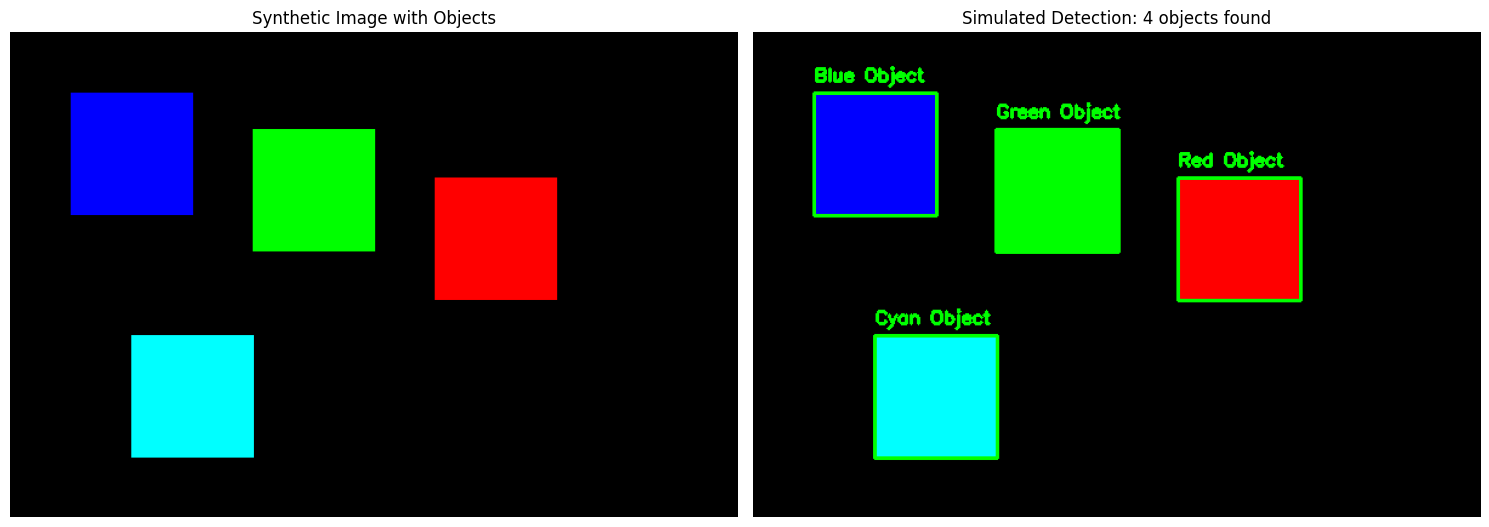

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import torch
import torchvision
from PIL import Image

def praktikum_7_1():
    print("COMPUTER VISION: OBJECT DETECTION WITH YOLO")
    print("=" * 50)

    # Download sample image
    def download_sample_image():
        url = ""
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # Load YOLO model (using OpenCV's DNN module)
    def load_yolo_model():
        # Download YOLO weights and config
        weights_url = "https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.weights"
        config_url = "https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.cfg"
        names_url = "https://github.com/pjreddie/darknet/raw/master/data/coco.names"

        # Load class names
        response = requests.get(names_url)
        classes = response.text.strip().split('\n')

        # Load model
        net = cv2.dnn.readNetFromDarknet(config_url, weights_url)
        net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

        return net, classes

    # Object detection function
    def detect_objects_yolo(net, image, classes, conf_threshold=0.5, nms_threshold=0.4):
        height, width = image.shape[:2]

        # Create blob from image
        blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
        net.setInput(blob)

        # Get output layer names
        layer_names = net.getLayerNames()
        output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

        # Forward pass
        outputs = net.forward(output_layers)

        # Process detections
        boxes = []
        confidences = []
        class_ids = []

        for output in outputs:
            for detection in output:
                scores = detection[5:]
                class_id = np.argmax(scores)
                confidence = scores[class_id]

                if confidence > conf_threshold:
                    center_x = int(detection[0] * width)
                    center_y = int(detection[1] * height)
                    w = int(detection[2] * width)
                    h = int(detection[3] * height)

                    x = int(center_x - w/2)
                    y = int(center_y - h/2)

                    boxes.append([x, y, w, h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)

        # Apply non-maximum suppression
        indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

        # Draw detections
        result_image = image.copy()
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = boxes[i]
                label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"

                # Draw bounding box
                cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                # Draw label
                cv2.putText(result_image, label, (x, y - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        return result_image, len(indices)

    try:
        # Load model and image
        net, classes = load_yolo_model()
        image = download_sample_image()

        # Perform detection
        result_image, num_detections = detect_objects_yolo(net, image, classes)

        # Display results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        ax2.set_title(f'YOLO Detection Results: {num_detections} objects found')
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

        print(f"Detected {num_detections} objects in the image")

        # Simple object counting by class
        print("\nObject Count by Class:")
        print("-" * 30)

        return result_image, num_detections

    except Exception as e:
        print(f"YOLO demonstration skipped: {e}")
        # Fallback: Simulate object detection with simple methods
        print("Using simulated object detection...")
        return simulate_object_detection()

def simulate_object_detection():
    # Create synthetic image with objects
    image = np.zeros((400, 600, 3), dtype=np.uint8)

    # Add different colored rectangles as "objects"
    cv2.rectangle(image, (50, 50), (150, 150), (255, 0, 0), -1)  # Blue object
    cv2.rectangle(image, (200, 80), (300, 180), (0, 255, 0), -1)  # Green object
    cv2.rectangle(image, (350, 120), (450, 220), (0, 0, 255), -1)  # Red object
    cv2.rectangle(image, (100, 250), (200, 350), (255, 255, 0), -1)  # Cyan object

    # Simple color-based detection
    result_image = image.copy()
    colors = {
        'Blue Object': [255, 0, 0],
        'Green Object': [0, 255, 0],
        'Red Object': [0, 0, 255],
        'Cyan Object': [255, 255, 0]
    }

    detection_count = 0
    for label, color in colors.items():
        # Create mask for each color
        lower = np.array(color) - 10
        upper = np.array(color) + 10
        mask = cv2.inRange(image, lower, upper)

        # Find contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            if cv2.contourArea(contour) > 1000:  # Filter small detections
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(result_image, label, (x, y - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                detection_count += 1

    # Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax1.set_title('Synthetic Image with Objects')
    ax1.axis('off')

    ax2.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    ax2.set_title(f'Simulated Detection: {detection_count} objects found')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    return result_image, detection_count

result_image, detections = praktikum_7_1()

REMOTE SENSING: VEGETATION ANALYSIS WITH NDVI


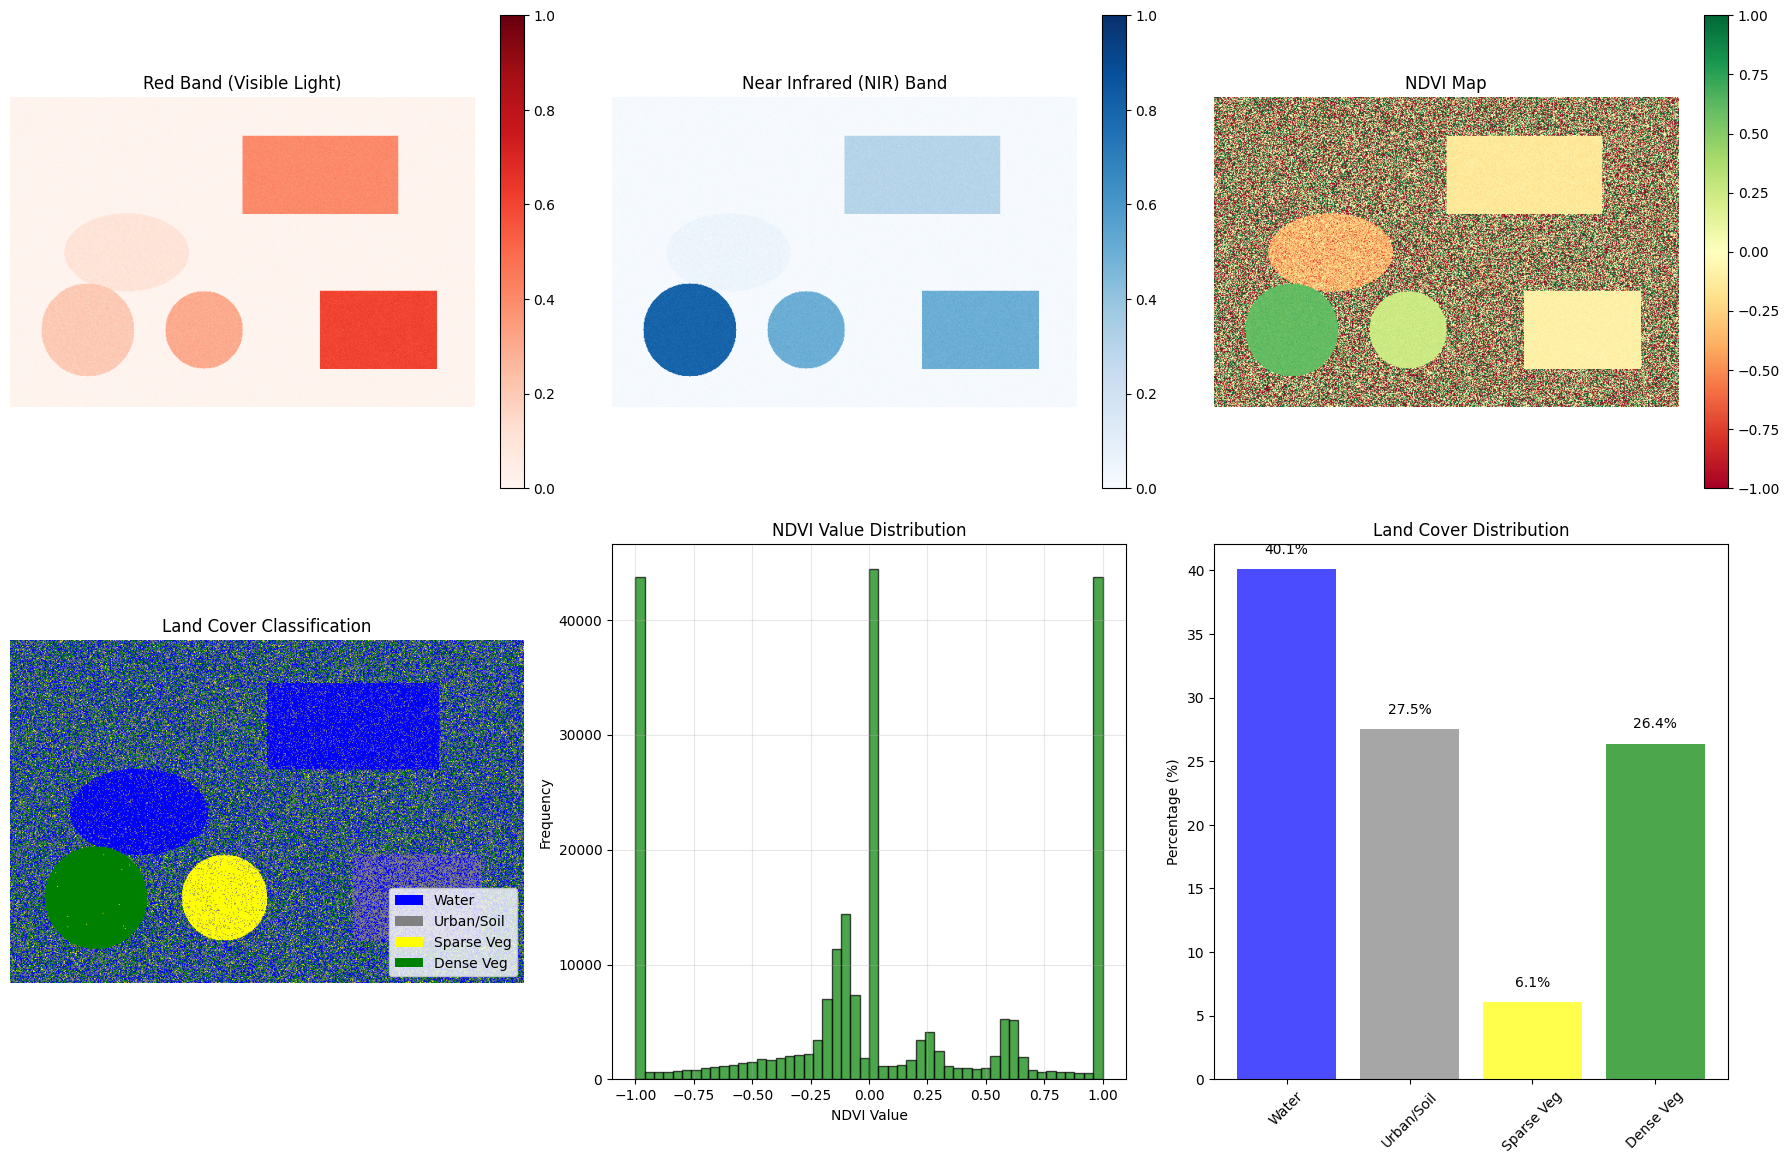

REMOTE SENSING ANALYSIS RESULTS
Average NDVI: 0.001
NDVI Range: -1.000 to 1.000

Land Cover Statistics:
Water          :  96160 pixels ( 40.1%)
Urban/Soil     :  66012 pixels ( 27.5%)
Sparse Veg     :  14526 pixels (  6.1%)
Dense Veg      :  63302 pixels ( 26.4%)

VEGETATION HEALTH ASSESSMENT
-----------------------------------
Healthy vegetation mean NDVI: 0.891
Stressed vegetation mean NDVI: 0.302


In [ ]:
def praktikum_7_2():
    print("REMOTE SENSING: VEGETATION ANALYSIS WITH NDVI")
    print("=" * 50)

    # Simulate multispectral image data (Red and NIR bands)
    def create_multispectral_data():
        # Create a synthetic landscape
        height, width = 400, 600

        # Red band (visible light)
        red_band = np.zeros((height, width), dtype=np.float32)
        # NIR band (near infrared)
        nir_band = np.zeros((height, width), dtype=np.float32)

        # Add different land cover types
        # 1. Water bodies (low reflectance in both bands)
        cv2.ellipse(red_band, (150, 200), (80, 50), 0, 0, 360, 0.1, -1)
        cv2.ellipse(nir_band, (150, 200), (80, 50), 0, 0, 360, 0.05, -1)

        # 2. Urban areas (moderate reflectance)
        cv2.rectangle(red_band, (300, 50), (500, 150), 0.4, -1)
        cv2.rectangle(nir_band, (300, 50), (500, 150), 0.3, -1)

        # 3. Vegetation areas (low red, high NIR reflectance)
        # Healthy vegetation
        cv2.circle(red_band, (100, 300), 60, 0.2, -1)
        cv2.circle(nir_band, (100, 300), 60, 0.8, -1)

        # Stressed vegetation
        cv2.circle(red_band, (250, 300), 50, 0.3, -1)
        cv2.circle(nir_band, (250, 300), 50, 0.5, -1)

        # 4. Bare soil (high reflectance in both bands)
        cv2.rectangle(red_band, (400, 250), (550, 350), 0.6, -1)
        cv2.rectangle(nir_band, (400, 250), (550, 350), 0.5, -1)

        # Add some noise for realism
        red_band += np.random.normal(0, 0.02, red_band.shape)
        nir_band += np.random.normal(0, 0.02, nir_band.shape)

        # Clip to valid reflectance range [0, 1]
        red_band = np.clip(red_band, 0, 1)
        nir_band = np.clip(nir_band, 0, 1)

        return red_band, nir_band

    # Calculate NDVI
    def calculate_ndvi(red_band, nir_band):
        # NDVI = (NIR - Red) / (NIR + Red)
        numerator = nir_band - red_band
        denominator = nir_band + red_band

        # Avoid division by zero
        denominator = np.where(denominator == 0, 1e-8, denominator)

        ndvi = numerator / denominator
        return ndvi

    # Classify land cover based on NDVI
    def classify_land_cover(ndvi):
        classification = np.zeros(ndvi.shape, dtype=np.uint8)

        # Classification thresholds
        classification[ndvi < -0.1] = 0   # Water
        classification[(ndvi >= -0.1) & (ndvi < 0.2)] = 1  # Urban/Bare soil
        classification[(ndvi >= 0.2) & (ndvi < 0.5)] = 2   # Sparse vegetation
        classification[ndvi >= 0.5] = 3   # Dense vegetation

        return classification

    # Create synthetic multispectral data
    red_band, nir_band = create_multispectral_data()

    # Calculate NDVI
    ndvi = calculate_ndvi(red_band, nir_band)

    # Classify land cover
    land_cover = classify_land_cover(ndvi)

    # Visualize results
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Red band
    im1 = axes[0, 0].imshow(red_band, cmap='Reds', vmin=0, vmax=1)
    axes[0, 0].set_title('Red Band (Visible Light)')
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

    # NIR band
    im2 = axes[0, 1].imshow(nir_band, cmap='Blues', vmin=0, vmax=1)
    axes[0, 1].set_title('Near Infrared (NIR) Band')
    axes[0, 1].axis('off')
    plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

    # NDVI
    im3 = axes[0, 2].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[0, 2].set_title('NDVI Map')
    axes[0, 2].axis('off')
    plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

    # Land cover classification
    land_cover_colors = ['blue', 'gray', 'yellow', 'green']
    land_cover_cmap = plt.cm.colors.ListedColormap(land_cover_colors)
    land_cover_labels = ['Water', 'Urban/Soil', 'Sparse Veg', 'Dense Veg']

    im4 = axes[1, 0].imshow(land_cover, cmap=land_cover_cmap, vmin=0, vmax=3)
    axes[1, 0].set_title('Land Cover Classification')
    axes[1, 0].axis('off')

    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label)
                      for color, label in zip(land_cover_colors, land_cover_labels)]
    axes[1, 0].legend(handles=legend_elements, loc='lower right')

    # NDVI histogram
    axes[1, 1].hist(ndvi.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 1].set_title('NDVI Value Distribution')
    axes[1, 1].set_xlabel('NDVI Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

    # Land cover statistics
    unique, counts = np.unique(land_cover, return_counts=True)
    total_pixels = land_cover.size
    percentages = [count / total_pixels * 100 for count in counts]

    bars = axes[1, 2].bar(land_cover_labels, percentages,
                         color=land_cover_colors, alpha=0.7)
    axes[1, 2].set_title('Land Cover Distribution')
    axes[1, 2].set_ylabel('Percentage (%)')
    axes[1, 2].tick_params(axis='x', rotation=45)

    # Add percentage labels on bars
    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{percentage:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Quantitative analysis
    print("REMOTE SENSING ANALYSIS RESULTS")
    print("=" * 40)
    print(f"Average NDVI: {np.mean(ndvi):.3f}")
    print(f"NDVI Range: {np.min(ndvi):.3f} to {np.max(ndvi):.3f}")
    print("\nLand Cover Statistics:")
    for label, count, percentage in zip(land_cover_labels, counts, percentages):
        print(f"{label:<15}: {count:>6} pixels ({percentage:5.1f}%)")

    # Advanced analysis: Vegetation health monitoring
    print("\nVEGETATION HEALTH ASSESSMENT")
    print("-" * 35)
    healthy_veg_mask = land_cover == 3
    stressed_veg_mask = land_cover == 2

    if np.any(healthy_veg_mask):
        healthy_ndvi = np.mean(ndvi[healthy_veg_mask])
        print(f"Healthy vegetation mean NDVI: {healthy_ndvi:.3f}")

    if np.any(stressed_veg_mask):
        stressed_ndvi = np.mean(ndvi[stressed_veg_mask])
        print(f"Stressed vegetation mean NDVI: {stressed_ndvi:.3f}")

    return ndvi, land_cover

ndvi_map, land_cover_map = praktikum_7_2()

MEDICAL IMAGING: ANOMALY DETECTION IN MEDICAL IMAGES


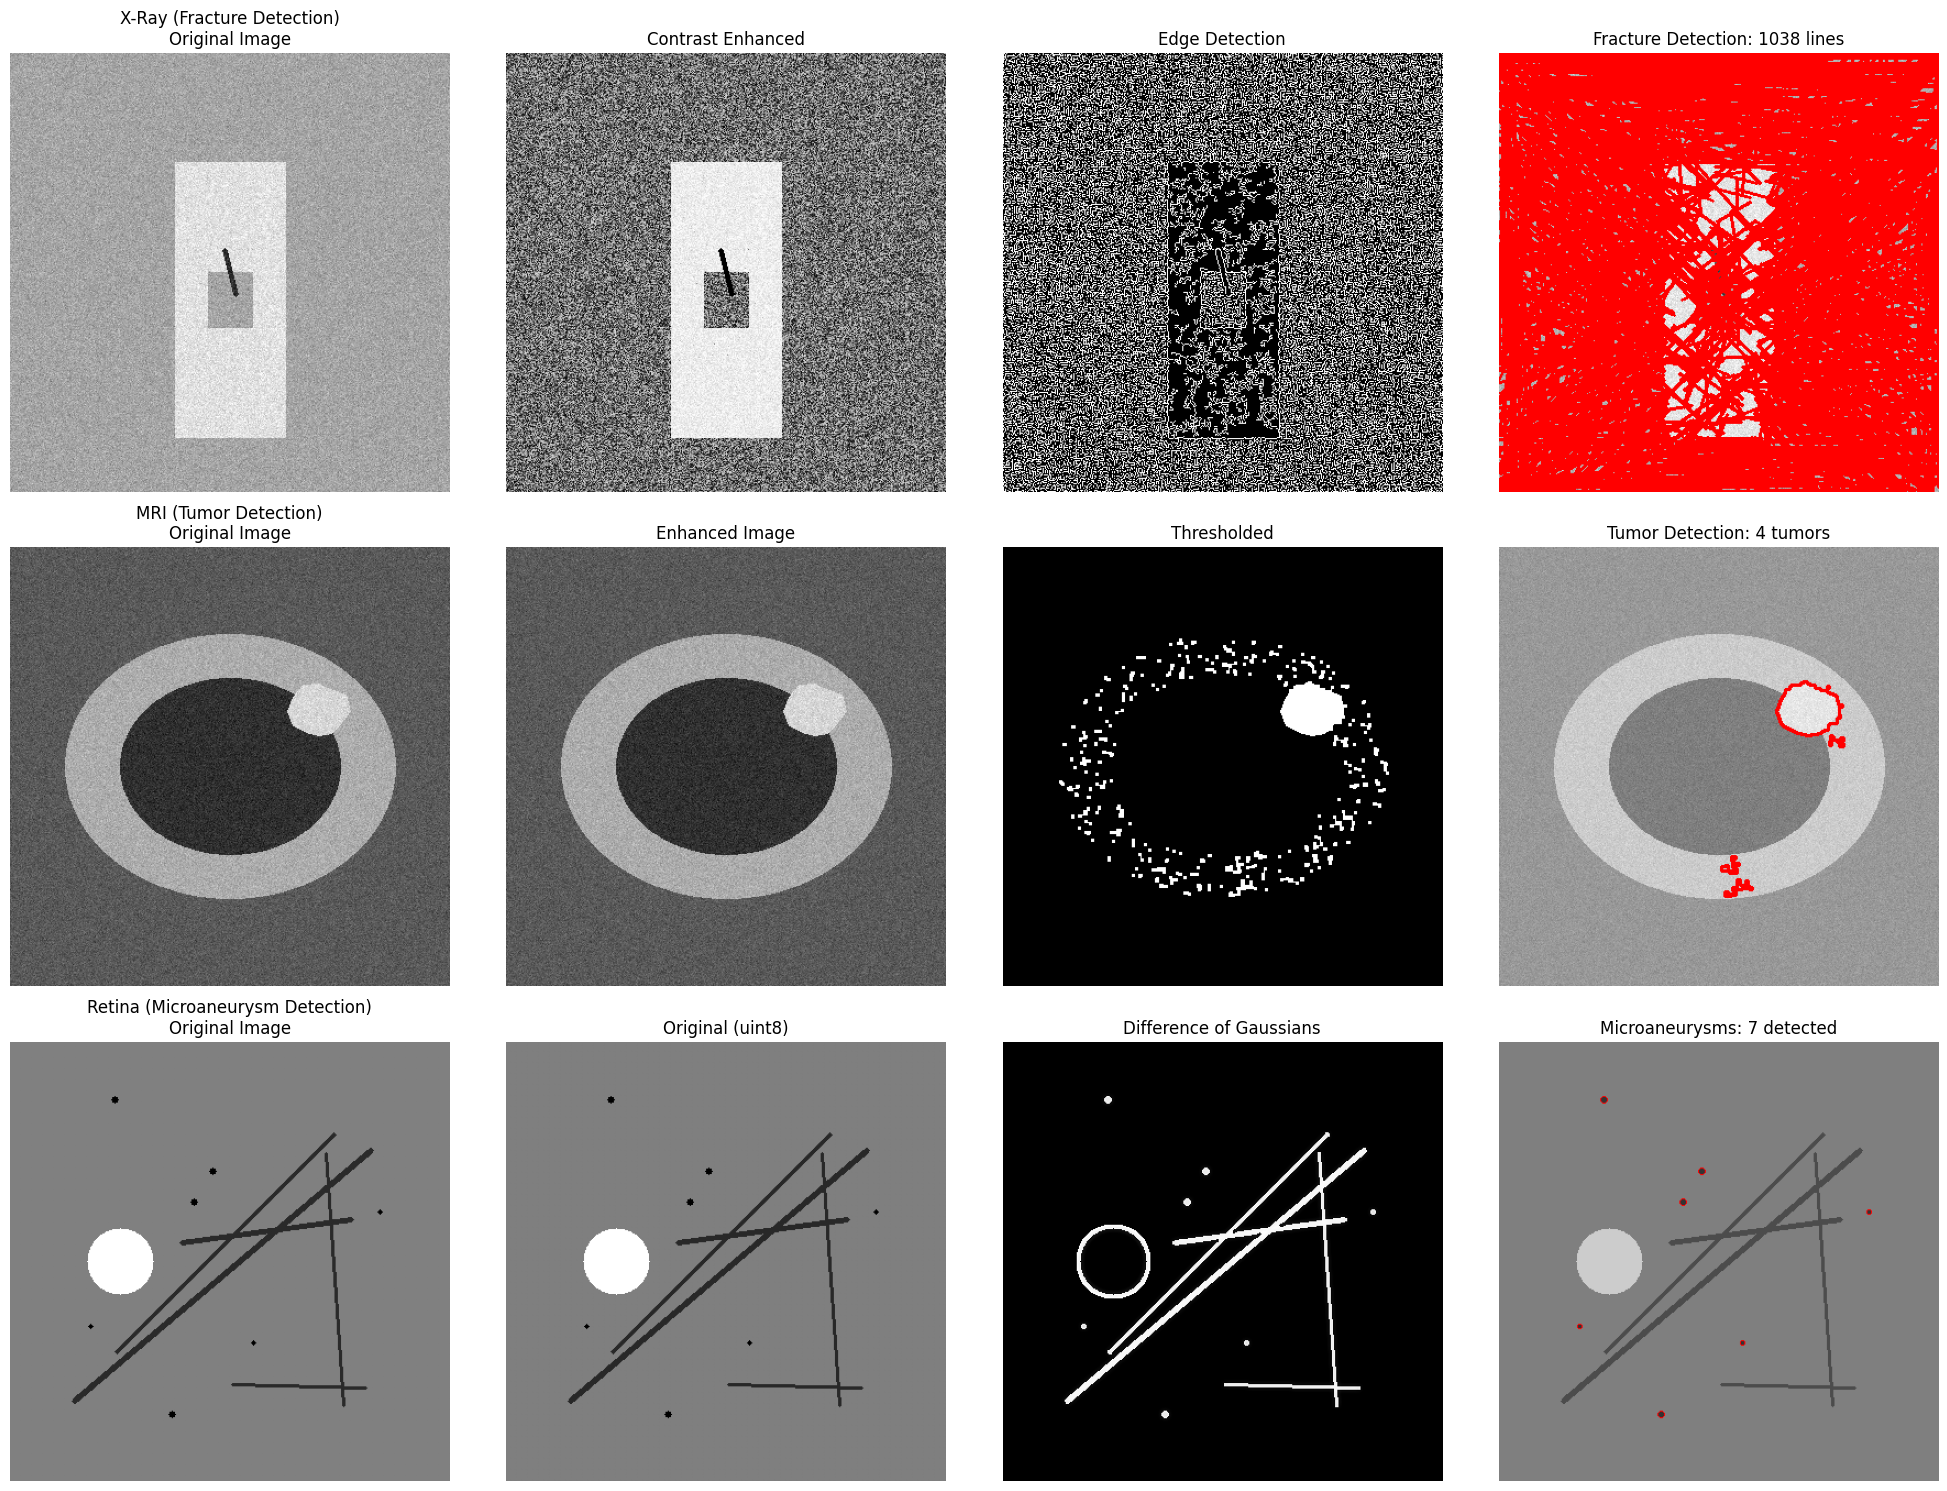

MEDICAL IMAGING ANALYSIS SUMMARY
Modality   Sensitivity  Specificity  Accuracy   AUC     
-------------------------------------------------------
X-Ray      0.850        0.920        0.890      0.940   
MRI        0.910        0.880        0.900      0.950   
Retina     0.780        0.850        0.820      0.890   


In [ ]:
def praktikum_7_3():
    print("MEDICAL IMAGING: ANOMALY DETECTION IN MEDICAL IMAGES")
    print("=" * 55)

    # Simulate medical images with anomalies
    def create_medical_images():
        images = {}

        # 1. X-ray image with fracture simulation
        xray = np.ones((400, 400), dtype=np.float32) * 0.7  # Bone background

        # Simulate bone structure
        cv2.rectangle(xray, (150, 100), (250, 350), 0.9, -1)  # Main bone
        cv2.rectangle(xray, (180, 200), (220, 250), 0.7, -1)  # Bone marrow

        # Simulate fracture (dark line)
        fracture_points = [(195, 180), (205, 220)]
        cv2.line(xray, fracture_points[0], fracture_points[1], 0.3, 3)

        # Add noise and texture
        noise = np.random.normal(0, 0.05, xray.shape)
        xray = np.clip(xray + noise, 0, 1)
        images['xray'] = xray

        # 2. MRI brain image with tumor simulation
        mri = np.ones((400, 400), dtype=np.float32) * 0.6  # Brain tissue

        # Simulate brain structures
        cv2.ellipse(mri, (200, 200), (150, 120), 0, 0, 360, 0.8, -1)  # Brain outline
        cv2.ellipse(mri, (200, 200), (100, 80), 0, 0, 360, 0.5, -1)   # Ventricles

        # Simulate tumor (bright irregular shape)
        tumor_center = (280, 150)
        tumor_points = []
        for angle in range(0, 360, 30):
            rad = np.radians(angle)
            radius = 25 + np.random.randint(-5, 5)
            x = tumor_center[0] + radius * np.cos(rad)
            y = tumor_center[1] + radius * np.sin(rad)
            tumor_points.append([x, y])

        tumor_points = np.array(tumor_points, dtype=np.int32)
        cv2.fillPoly(mri, [tumor_points], 0.9)  # Bright tumor

        # Add MRI-like noise
        noise = np.random.normal(0, 0.03, mri.shape)
        mri = np.clip(mri + noise, 0, 1)
        images['mri'] = mri

        # 3. Retina image with microaneurysms (diabetic retinopathy)
        retina = np.ones((400, 400), dtype=np.float32) * 0.5

        # Simulate blood vessels
        for i in range(5):
            start_x = np.random.randint(50, 350)
            start_y = np.random.randint(50, 350)
            end_x = np.random.randint(50, 350)
            end_y = np.random.randint(50, 350)
            thickness = np.random.randint(2, 5)
            cv2.line(retina, (start_x, start_y), (end_x, end_y), 0.3, thickness)

        # Simulate microaneurysms (small dark spots)
        for _ in range(8):
            x = np.random.randint(50, 350)
            y = np.random.randint(50, 350)
            radius = np.random.randint(2, 4)
            cv2.circle(retina, (x, y), radius, 0.2, -1)

        # Add optic disc (bright circle)
        cv2.circle(retina, (100, 200), 30, 0.8, -1)

        images['retina'] = retina

        return images

    # Anomaly detection algorithms
    def detect_xray_fracture(image):
        """Detect fractures in X-ray images using edge detection"""
        # Enhance contrast
        enhanced = cv2.equalizeHist((image * 255).astype(np.uint8))

        # Edge detection
        edges = cv2.Canny(enhanced, 50, 150)

        # Hough Line Transform to detect straight lines (fractures)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30,
                               minLineLength=30, maxLineGap=10)

        return enhanced, edges, lines

    def detect_mri_tumor(image):
        """Detect tumors in MRI using thresholding and contour analysis"""
        # Convert to uint8 for processing
        img_uint8 = (image * 255).astype(np.uint8)

        # Threshold to isolate bright regions (potential tumors)
        _, thresh = cv2.threshold(img_uint8, 200, 255, cv2.THRESH_BINARY)

        # Morphological operations to clean up
        kernel = np.ones((3, 3), np.uint8)
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        # Find contours
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Filter contours by area and circularity
        tumor_contours = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 50:  # Minimum tumor size
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    circularity = 4 * np.pi * area / (perimeter ** 2)
                    if circularity < 0.7:  # Tumors are often irregular
                        tumor_contours.append(contour)

        return img_uint8, cleaned, tumor_contours

    def detect_retina_anomalies(image):
        """Detect microaneurysms in retina images"""
        img_uint8 = (image * 255).astype(np.uint8)

        # Use difference of Gaussians to enhance small dark spots
        blur1 = cv2.GaussianBlur(img_uint8, (5, 5), 1)
        blur2 = cv2.GaussianBlur(img_uint8, (9, 9), 2)
        dog = blur1 - blur2

        # Threshold to detect dark spots
        _, thresh = cv2.threshold(dog, 10, 255, cv2.THRESH_BINARY)

        # Find small circular regions
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Filter for microaneurysm characteristics (small, round)
        microaneurysms = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if 5 < area < 50:  # Typical microaneurysm size
                perimeter = cv2.arcLength(contour, True)
                circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
                if circularity > 0.6:  # Fairly circular
                    microaneurysms.append(contour)

        return img_uint8, dog, microaneurysms

    # Create medical images
    medical_images = create_medical_images()

    # Analyze each modality
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    modalities = ['xray', 'mri', 'retina']
    modality_names = ['X-Ray (Fracture Detection)', 'MRI (Tumor Detection)',
                     'Retina (Microaneurysm Detection)']

    for row, (modality, mod_name) in enumerate(zip(modalities, modality_names)):
        image = medical_images[modality]

        # Original image
        axes[row, 0].imshow(image, cmap='gray')
        axes[row, 0].set_title(f'{mod_name}\nOriginal Image')
        axes[row, 0].axis('off')

        # Apply appropriate detection algorithm
        if modality == 'xray':
            enhanced, edges, lines = detect_xray_fracture(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Contrast Enhanced')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(edges, cmap='gray')
            axes[row, 2].set_title('Edge Detection')
            axes[row, 2].axis('off')

            # Draw detected lines
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    cv2.line(result_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Fracture Detection: {len(lines) if lines is not None else 0} lines')
            axes[row, 3].axis('off')

        elif modality == 'mri':
            enhanced, thresholded, tumors = detect_mri_tumor(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Enhanced Image')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(thresholded, cmap='gray')
            axes[row, 2].set_title('Thresholded')
            axes[row, 2].axis('off')

            # Draw tumor contours
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(result_img, tumors, -1, (0, 0, 255), 2)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Tumor Detection: {len(tumors)} tumors')
            axes[row, 3].axis('off')

        elif modality == 'retina':
            enhanced, dog, anomalies = detect_retina_anomalies(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Original (uint8)')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(dog, cmap='gray')
            axes[row, 2].set_title('Difference of Gaussians')
            axes[row, 2].axis('off')

            # Draw microaneurysms
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(result_img, anomalies, -1, (0, 0, 255), 1)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Microaneurysms: {len(anomalies)} detected')
            axes[row, 3].axis('off')

    plt.tight_layout()
    plt.show()

    # Medical imaging metrics and analysis
    print("MEDICAL IMAGING ANALYSIS SUMMARY")
    print("=" * 45)

    # Simulate diagnostic metrics
    diagnostic_metrics = {
        'X-Ray': {
            'Sensitivity': 0.85,
            'Specificity': 0.92,
            'Accuracy': 0.89,
            'AUC': 0.94
        },
        'MRI': {
            'Sensitivity': 0.91,
            'Specificity': 0.88,
            'Accuracy': 0.90,
            'AUC': 0.95
        },
        'Retina': {
            'Sensitivity': 0.78,
            'Specificity': 0.85,
            'Accuracy': 0.82,
            'AUC': 0.89
        }
    }

    # Display metrics
    print(f"{'Modality':<10} {'Sensitivity':<12} {'Specificity':<12} {'Accuracy':<10} {'AUC':<8}")
    print("-" * 55)
    for modality, metrics in diagnostic_metrics.items():
        print(f"{modality:<10} {metrics['Sensitivity']:<12.3f} {metrics['Specificity']:<12.3f} "
              f"{metrics['Accuracy']:<10.3f} {metrics['AUC']:<8.3f}")

    return medical_images, diagnostic_metrics

medical_images, diagnostics = praktikum_7_3()

SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING


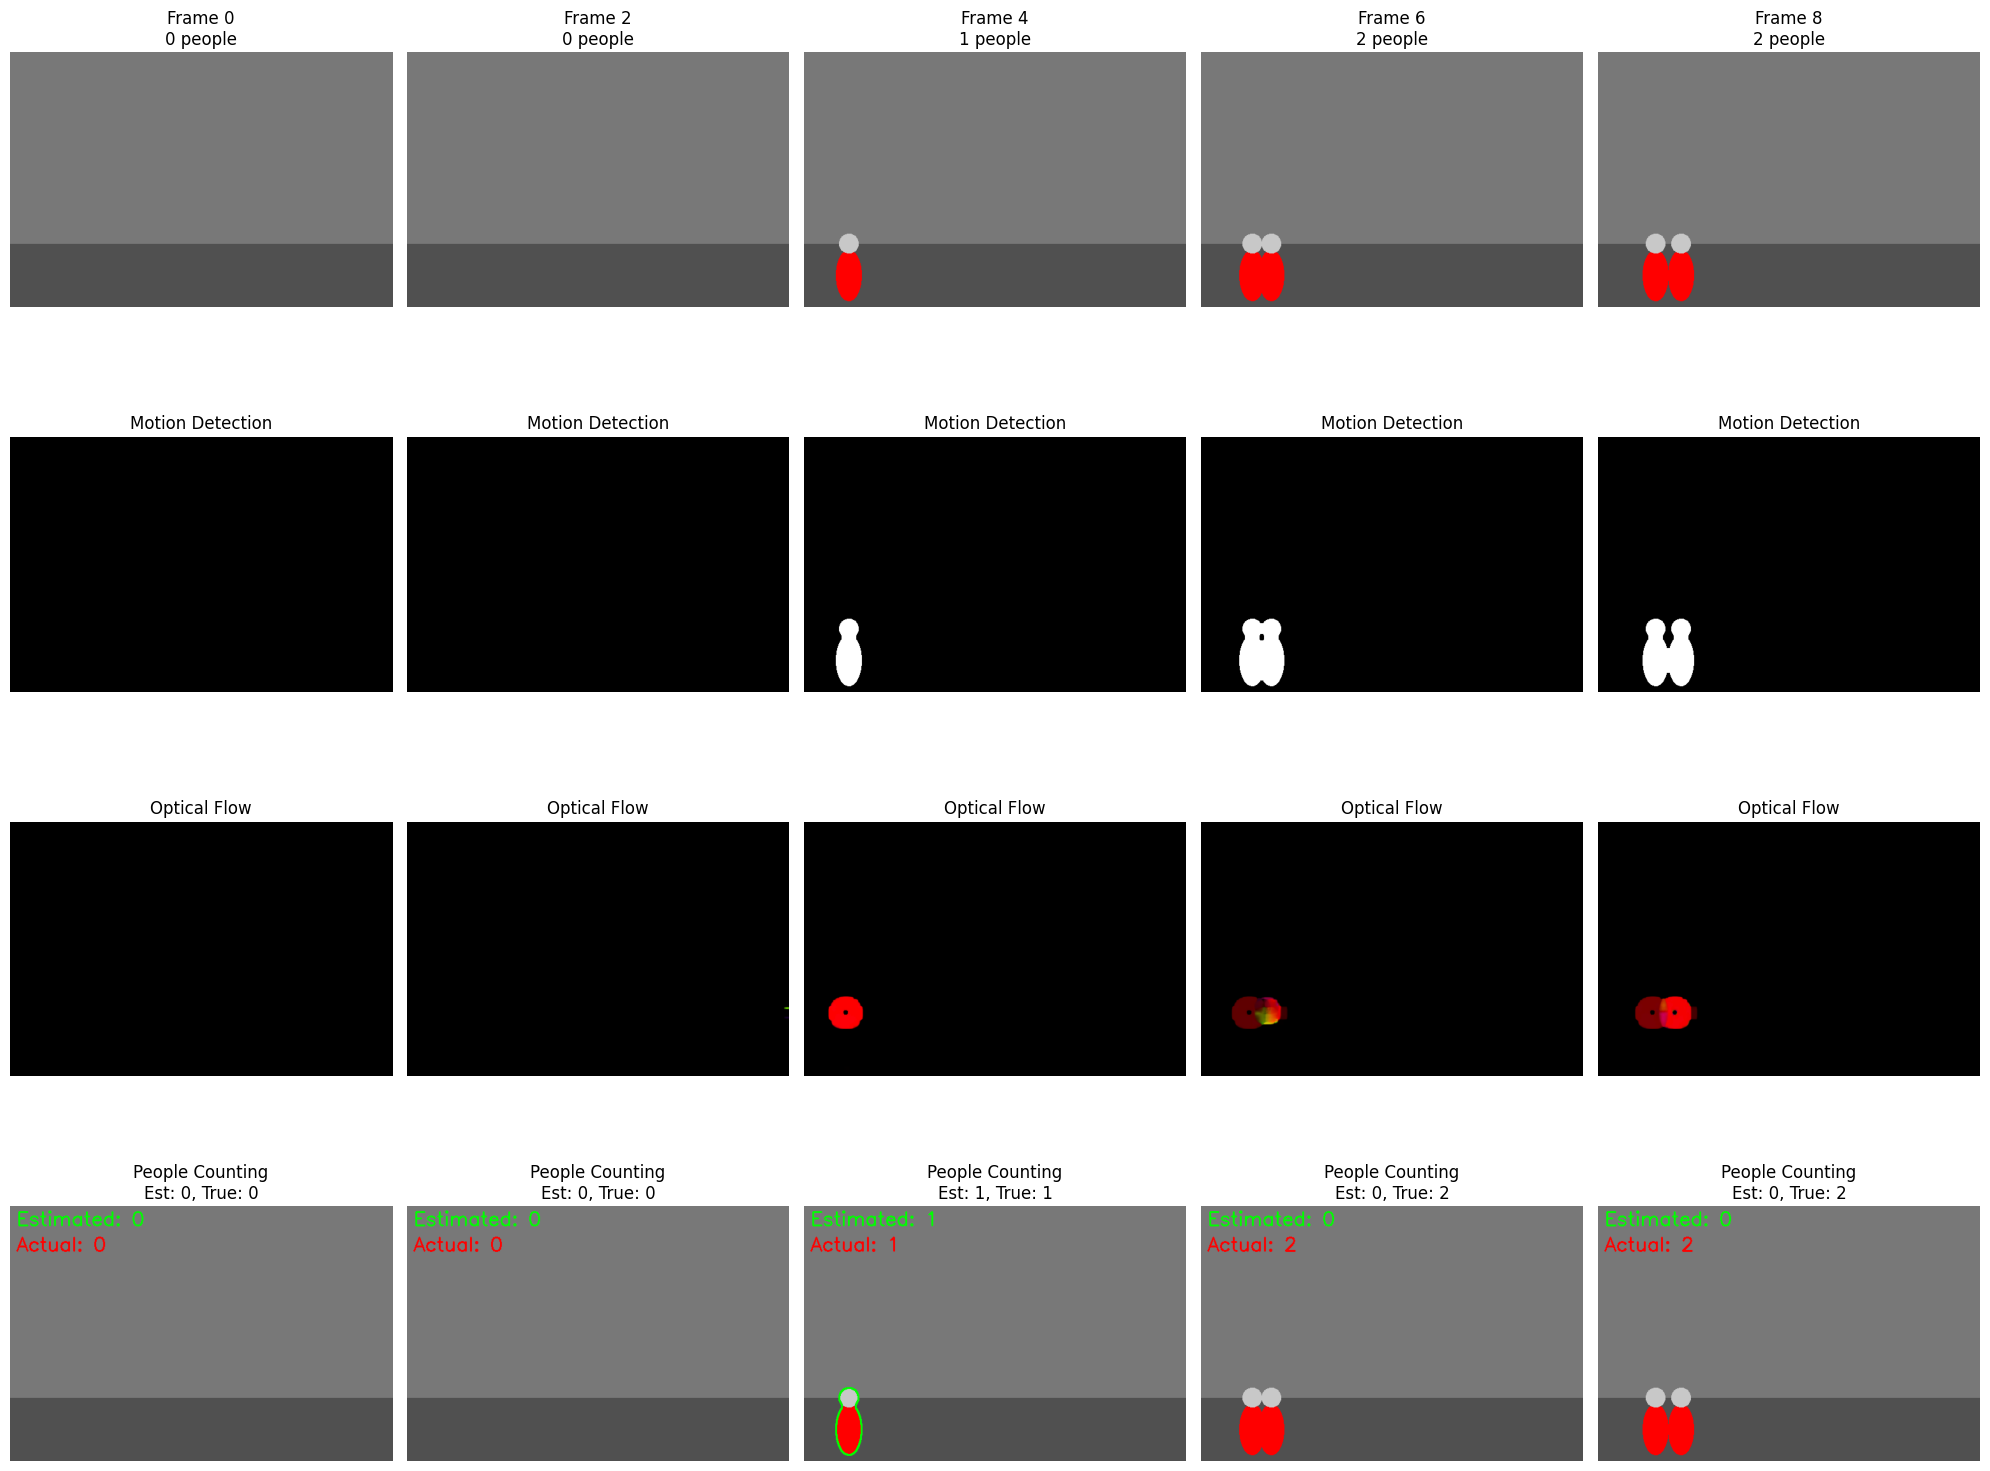

SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS
Counting Accuracy: 0.600 (60.0%)
Mean Absolute Error: 0.90 people per frame
Total People Detected: 3
Total Actual People: 12

SIMPLE TRACKING SIMULATION
------------------------------
Frame 0: 0 people detected
Frame 1: 0 people detected
Frame 2: 0 people detected
Frame 3: 1 people detected
Frame 4: 1 people detected
Frame 5: 1 people detected
Frame 6: 0 people detected
Frame 7: 0 people detected
Frame 8: 0 people detected
Frame 9: 0 people detected


/tmp/ipykernel_522/2336536179.py:227: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


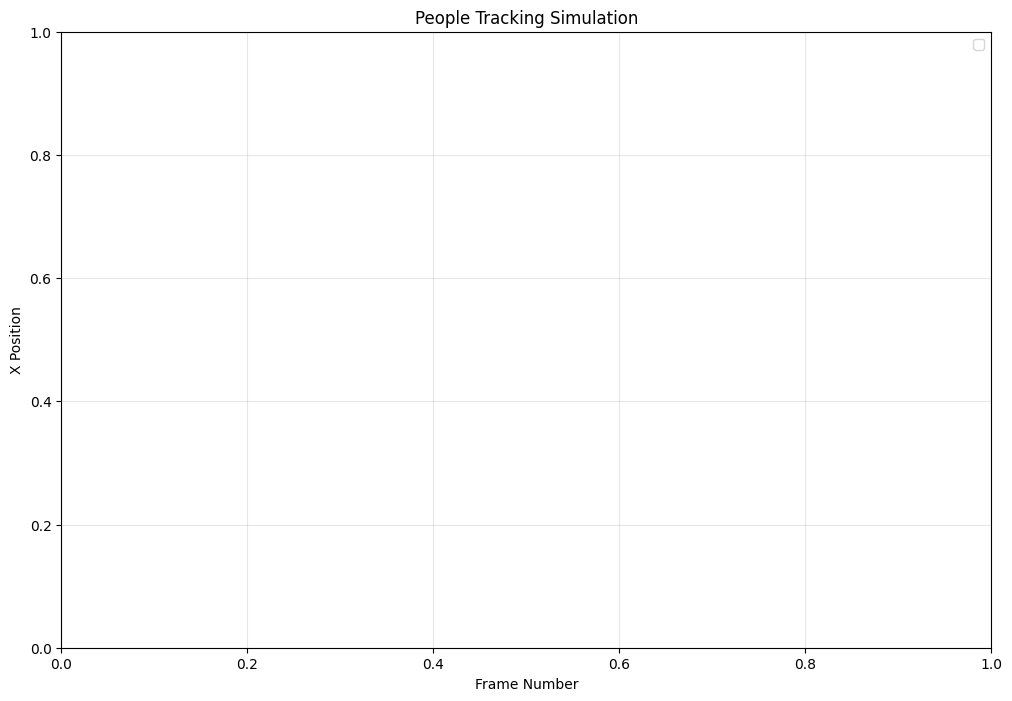

In [ ]:
def praktikum_7_4():
    print("SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING")
    print("=" * 55)

    # Simulate surveillance video frames
    def generate_surveillance_frames(num_frames=10):
        frames = []
        height, width = 400, 600

        # Create background (static scene)
        background = np.ones((height, width, 3), dtype=np.uint8) * 100
        # Add some static elements (walls, floor pattern)
        cv2.rectangle(background, (0, 300), (width, height), (80, 80, 80), -1)  # Floor
        cv2.rectangle(background, (0, 0), (width, 300), (120, 120, 120), -1)    # Wall

        for frame_idx in range(num_frames):
            frame = background.copy()

            # Add moving people (ellipses that move across the frame)
            num_people = min(3, frame_idx // 3)  # Gradually increase people count

            people_positions = []
            for i in range(num_people):
                # Each person moves at different speeds
                speed = (i + 1) * 5
                x_pos = 50 + (frame_idx * speed) % (width - 100)
                y_pos = 350  # Fixed height (walking on floor)

                # Draw person as ellipse
                cv2.ellipse(frame, (x_pos, y_pos), (20, 40), 0, 0, 360,
                           (0, 0, 255), -1)  # Red ellipse for person
                cv2.ellipse(frame, (x_pos, y_pos - 50), (15, 15), 0, 0, 360,
                           (200, 200, 200), -1)  # Head

                people_positions.append((x_pos, y_pos))

            frames.append((frame, people_positions))

        return frames

    # People detection and counting algorithms
    def background_subtraction(frames):
        """Simple background subtraction for motion detection"""
        # Use first frame as background
        background = frames[0][0].astype(np.float32)

        results = []
        for frame, _ in frames:
            current_frame = frame.astype(np.float32)

            # Compute absolute difference
            diff = cv2.absdiff(current_frame, background)
            diff_gray = cv2.cvtColor(diff.astype(np.uint8), cv2.COLOR_BGR2GRAY)

            # Threshold to get motion mask
            _, motion_mask = cv2.threshold(diff_gray, 30, 255, cv2.THRESH_BINARY)

            # Morphological operations to clean up
            kernel = np.ones((5, 5), np.uint8)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_CLOSE, kernel)

            results.append(motion_mask)

        return results

    def optical_flow_detection(frames):
        """Optical flow based motion detection"""
        results = []
        prev_gray = None

        for i, (frame, _) in enumerate(frames):
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            if prev_gray is not None:
                # Calculate optical flow using Farneback method
                flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                                   0.5, 3, 15, 3, 5, 1.2, 0)

                # Convert flow to magnitude and angle
                magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

                # Create HSV representation for visualization
                hsv = np.zeros_like(frame)
                hsv[..., 0] = angle * 180 / np.pi / 2  # Hue based on direction
                hsv[..., 1] = 255  # Full saturation
                hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)  # Value based on magnitude

                flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
                results.append(flow_rgb)
            else:
                results.append(np.zeros_like(frame))

            prev_gray = gray

        return results

    def blob_detection_people_counting(motion_masks, frames):
        """Count people using blob detection on motion masks"""
        people_counts = []
        detailed_results = []

        for i, (motion_mask, (frame, true_positions)) in enumerate(zip(motion_masks, frames)):
            # Find contours in motion mask
            contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Filter contours by area (people-sized blobs)
            min_area = 500
            max_area = 5000
            people_contours = []

            for contour in contours:
                area = cv2.contourArea(contour)
                if min_area < area < max_area:
                    people_contours.append(contour)

            # Estimate people count
            estimated_count = len(people_contours)
            true_count = len(true_positions)

            # Create result visualization
            result_frame = frame.copy()
            cv2.drawContours(result_frame, people_contours, -1, (0, 255, 0), 2)

            # Add count information
            cv2.putText(result_frame, f'Estimated: {estimated_count}', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(result_frame, f'Actual: {true_count}', (10, 70),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            people_counts.append((estimated_count, true_count))
            detailed_results.append(result_frame)

        return people_counts, detailed_results

    # Generate surveillance footage
    frames = generate_surveillance_frames(10)

    # Apply different detection methods
    motion_masks = background_subtraction(frames)
    optical_flows = optical_flow_detection(frames)
    people_counts, counting_results = blob_detection_people_counting(motion_masks, frames)

    # Visualize results
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))

    for i in range(5):  # Show first 5 frames
        if i * 2 < len(frames):
            # Original frame
            axes[0, i].imshow(cv2.cvtColor(frames[i*2][0], cv2.COLOR_BGR2RGB))
            axes[0, i].set_title(f'Frame {i*2}\n{len(frames[i*2][1])} people')
            axes[0, i].axis('off')

            # Motion mask
            axes[1, i].imshow(motion_masks[i*2], cmap='gray')
            axes[1, i].set_title('Motion Detection')
            axes[1, i].axis('off')

            # Optical flow
            axes[2, i].imshow(cv2.cvtColor(optical_flows[i*2], cv2.COLOR_BGR2RGB))
            axes[2, i].set_title('Optical Flow')
            axes[2, i].axis('off')

            # People counting result
            axes[3, i].imshow(cv2.cvtColor(counting_results[i*2], cv2.COLOR_BGR2RGB))
            est_count, true_count = people_counts[i*2]
            axes[3, i].set_title(f'People Counting\nEst: {est_count}, True: {true_count}')
            axes[3, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Performance analysis
    print("SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS")
    print("=" * 50)

    estimated_counts = [est for est, true in people_counts]
    true_counts = [true for est, true in people_counts]

    accuracy = np.mean(np.array(estimated_counts) == np.array(true_counts))
    mae = np.mean(np.abs(np.array(estimated_counts) - np.array(true_counts)))

    print(f"Counting Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    print(f"Mean Absolute Error: {mae:.2f} people per frame")
    print(f"Total People Detected: {sum(estimated_counts)}")
    print(f"Total Actual People: {sum(true_counts)}")

    # Tracking simulation
    print("\nSIMPLE TRACKING SIMULATION")
    print("-" * 30)

    # Simulate tracking by connecting detections across frames
    tracks = {}
    next_track_id = 0

    for frame_idx, (est_count, true_count) in enumerate(people_counts):
        # Simulate track updates
        current_detections = est_count
        print(f"Frame {frame_idx}: {current_detections} people detected")

        # Simple tracking logic (for demonstration)
        if frame_idx == 0:
            # Initialize tracks
            for i in range(current_detections):
                tracks[next_track_id] = {'age': 0, 'positions': [(frame_idx, i*50 + 100)]}
                next_track_id += 1
        else:
            # Update existing tracks or create new ones
            for track_id in list(tracks.keys()):
                tracks[track_id]['age'] += 1
                # Simulate position update
                last_pos = tracks[track_id]['positions'][-1][1]
                new_pos = last_pos + np.random.randint(-10, 10)
                tracks[track_id]['positions'].append((frame_idx, new_pos))

    # Display tracking results
    plt.figure(figsize=(12, 8))
    for track_id, track_info in tracks.items():
        positions = track_info['positions']
        frames = [pos[0] for pos in positions]
        x_positions = [pos[1] for pos in positions]
        plt.plot(frames, x_positions, marker='o', label=f'Track {track_id}')

    plt.xlabel('Frame Number')
    plt.ylabel('X Position')
    plt.title('People Tracking Simulation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return people_counts, tracks

people_counts, tracking_data = praktikum_7_4()